# Multiscale Modeling of Biological Systems: Neuroscience - Assignment


## Setup

Follow the setup steps in `README.md`. Then run the cells below in order.


In [1]:
import rsatoolbox as rsa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.get_backend())

from core import SantoroDataset, MODEL_CLASSES, extract_activations

from torch.utils.data import DataLoader
from torch import Tensor


module://matplotlib_inline.backend_inline


## Part I


In [2]:
dataset = SantoroDataset()

categories = set(dataset.categories)

print(f"Unique Categories ({len(categories)}):", categories)
print("Models:", ", ".join(MODEL_CLASSES.keys()))

Unique Categories (73): {'bell', 'brush', 'firework', 'hairdryer', 'pig', 'insect', 'metal', 'keys', 'synthesizer', 'bass', 'accordion', 'gun', 'clarinet', 'duck', 'wood', 'dice', 'chicken', 'chimes', 'waves', 'baby', 'guitar', 'ensamble', 'siren', 'paper', 'monkey', 'river', 'zipper', 'elastic', 'glass', 'thunder', 'horse', 'door', 'goat', 'bird', 'organ', 'sheep', 'drum', 'dog', 'bottle', 'cat', 'bells', 'whistle', 'piano', 'wolf', 'flute', 'rain', 'motor', 'toothbrush', 'man', 'clock', 'bagpipe', 'percussion', 'harp', 'wind', 'woman', 'typewriter', 'ocean', 'sitar', 'engine', 'cow', 'waterfall', 'toilet', 'violin', 'cutting', 'dishes', 'car', 'harmonica', 'horn', 'water', 'phone', 'sawing', 'trumpet', 'hammer'}
Models: waveform, uninspired, inspired


### Brain data

Each row is one sound. Each column is one voxel, a small part of the brain scan.


In [3]:
# Create rsatoolbox dataset:
def calculate_rdm(tensor: Tensor):
    rsa_data = rsa.data.Dataset(
        tensor.detach().cpu().reshape(tensor.shape[0], -1).numpy() 
    )

    return rsa.rdm.calc_rdm(rsa_data, method='correlation')


# Fix just in case it does not show up on its own
def show_rdm(rdm, **kwargs):
    fig, axes, handles = rsa.vis.show_rdm(rdm, **kwargs)
    plt.show()

### 1. RDMs


#### a) STG brain data


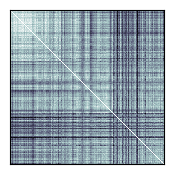

In [4]:
rdm_stg = calculate_rdm(dataset.brain_responses)

show_rdm(rdm_stg)

#### b) Untrained models

We use five random versions of each model. We calculate an RDM for each layer and keep all the results. The plots show the first run.


Untrained waveform, run0: done
Untrained waveform, run1: done
Untrained waveform, run2: done
Untrained waveform, run3: done
Untrained waveform, run4: done


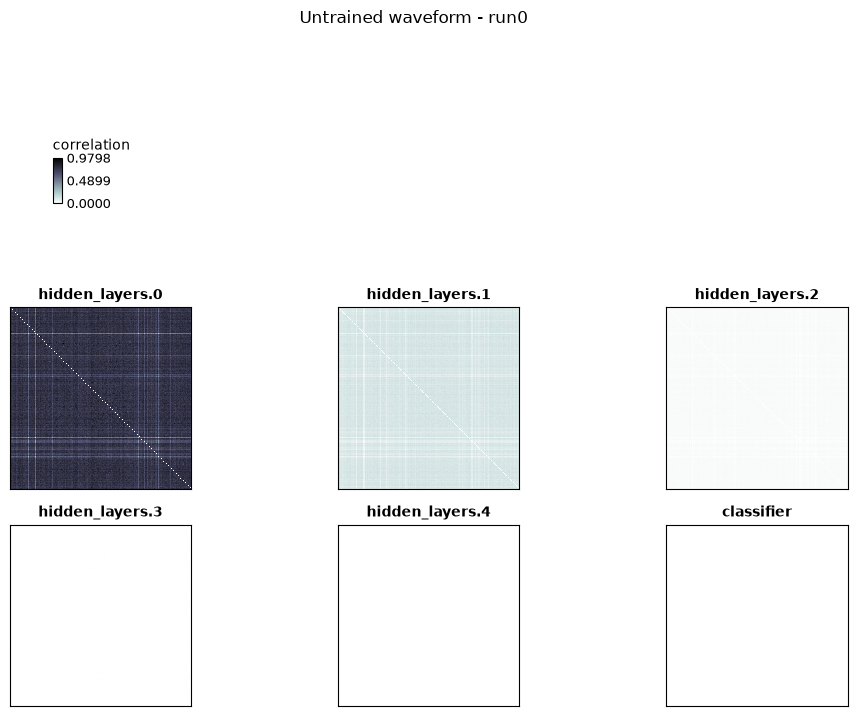

Untrained uninspired, run0: done
Untrained uninspired, run1: done
Untrained uninspired, run2: done
Untrained uninspired, run3: done
Untrained uninspired, run4: done


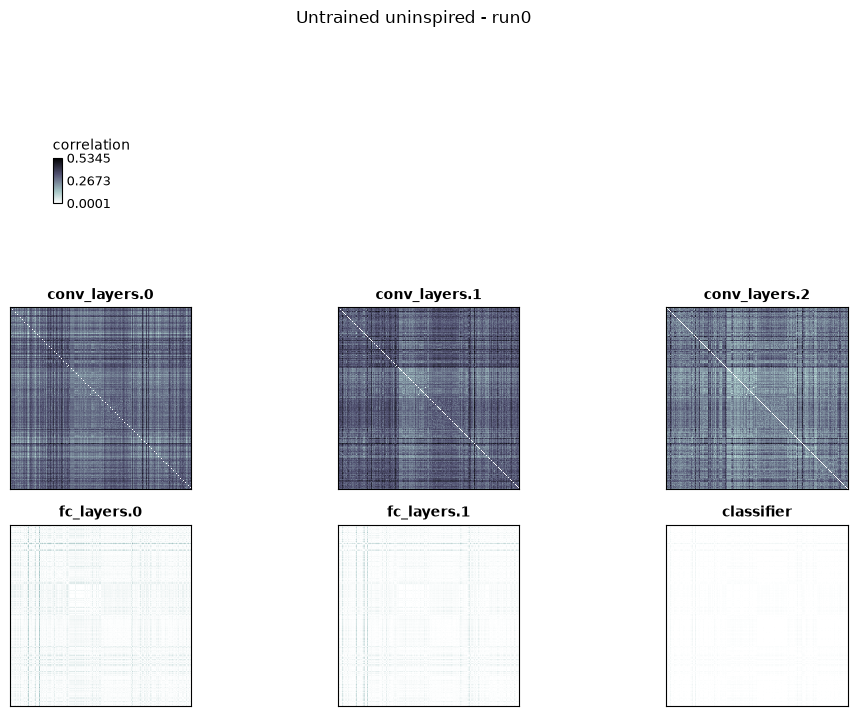

Untrained inspired, run0: done
Untrained inspired, run1: done
Untrained inspired, run2: done
Untrained inspired, run3: done
Untrained inspired, run4: done


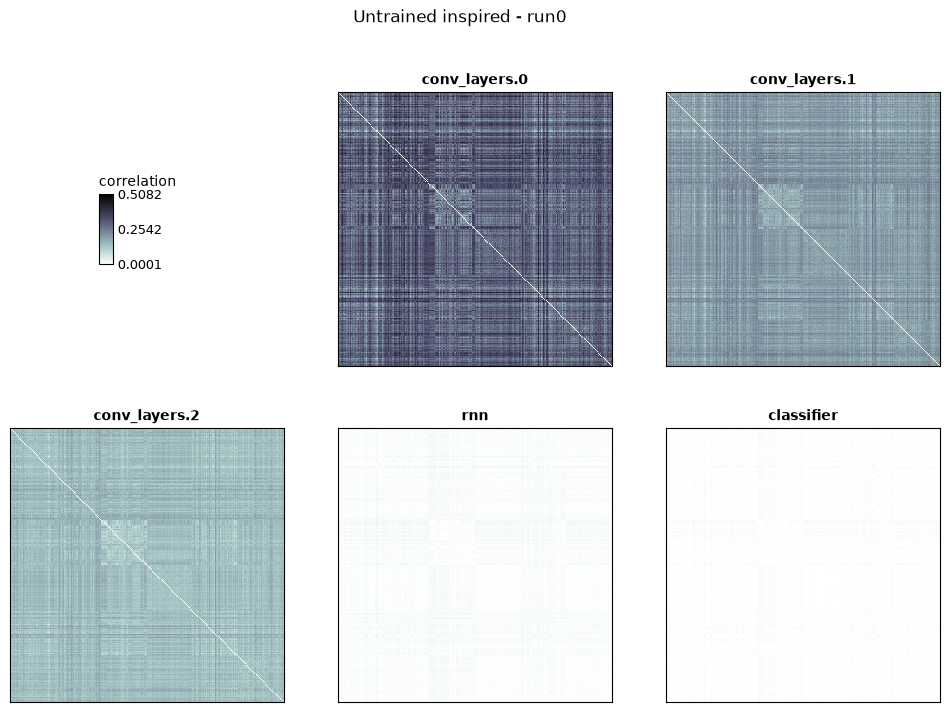

In [5]:
import torch

# Save all three models and all five random initializations.
# These are new random models, not the original starting weights of the trained runs.
untrained_rdms = {}
loader = DataLoader(dataset, batch_size=16, shuffle=False)

for model_name, ModelClass in MODEL_CLASSES.items():
    untrained_rdms[model_name] = {}
    for seed in range(5):
        torch.manual_seed(seed)
        model = ModelClass(num_classes=50)
        activations = extract_activations(loader, model)
        untrained_rdms[model_name][f'run{seed}'] = {
            layer_name: calculate_rdm(layer_act)
            for layer_name, layer_act in activations.items()
        }
        print(f'Untrained {model_name}, run{seed}: done')
        del activations, model

    layer_rdms = untrained_rdms[model_name]['run0']
    all_rdms = rsa.rdm.concat(*layer_rdms.values())
    all_rdms.rdm_descriptors['layer'] = list(layer_rdms)
    fig, axes, handles = rsa.vis.show_rdm(
        all_rdms, rdm_descriptor='layer', n_column=3,
        show_colorbar='figure', figsize=(12, 8),
    )
    fig.suptitle(f'Untrained {model_name} - run0')
    plt.show()

#### c) Trained models

We load the saved weights from five training runs of each model. We calculate an RDM for each layer, using the same sound order as the brain data. The plots show the first run.

For Inspired, the helper function shows the final GRU layer's output as one `rnn` result. It does not show both GRU layers separately.


waveform, run0: 6 layer RDMs
waveform, run1: 6 layer RDMs
waveform, run2: 6 layer RDMs
waveform, run3: 6 layer RDMs
waveform, run4: 6 layer RDMs


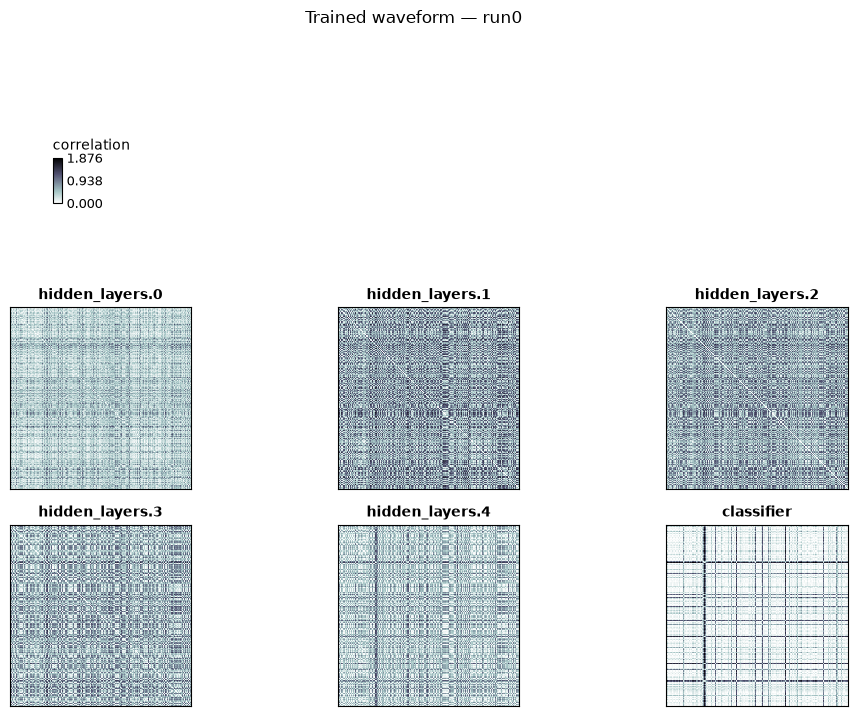

uninspired, run0: 6 layer RDMs
uninspired, run1: 6 layer RDMs
uninspired, run2: 6 layer RDMs
uninspired, run3: 6 layer RDMs
uninspired, run4: 6 layer RDMs


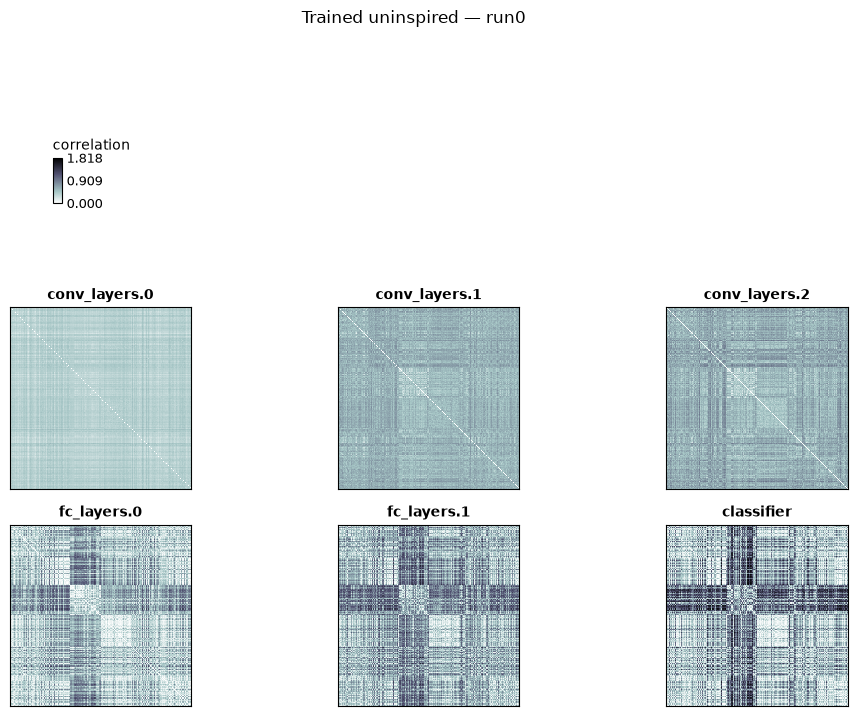

inspired, run0: 5 layer RDMs
inspired, run1: 5 layer RDMs
inspired, run2: 5 layer RDMs
inspired, run3: 5 layer RDMs
inspired, run4: 5 layer RDMs


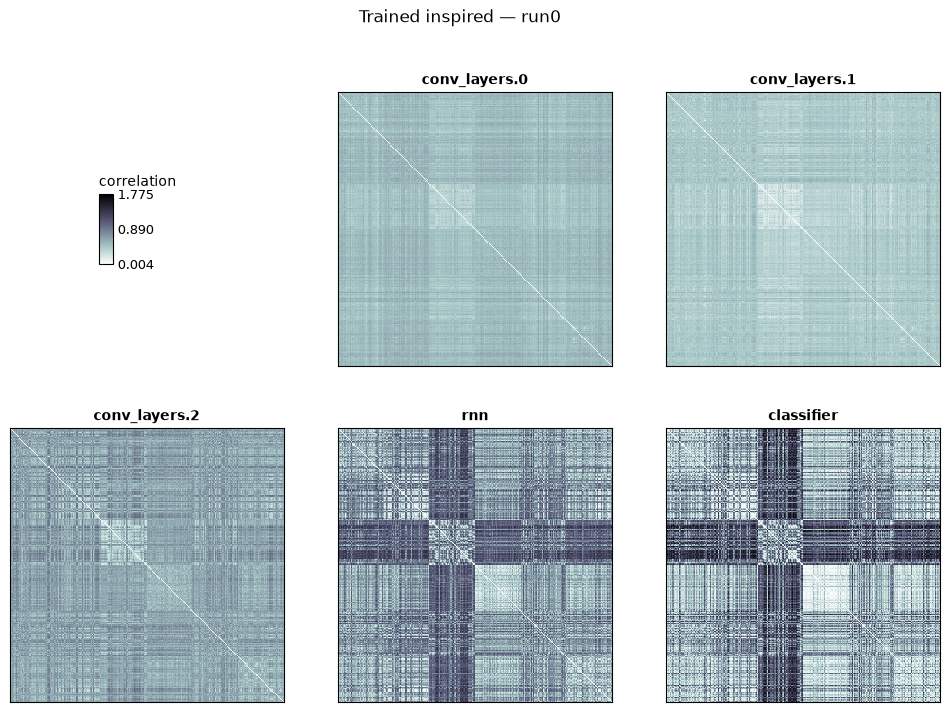

In [6]:
from pathlib import Path
import torch
import core

models_dir = Path(core.__file__).resolve().parent / 'models'
loader = DataLoader(dataset, batch_size=16, shuffle=False)

# trained_rdms[model_name][run_name][layer_name]
trained_rdms = {}

for model_name, ModelClass in MODEL_CLASSES.items():
    checkpoints = sorted(models_dir.glob(f'{model_name}_run*_best.pt'))
    if not checkpoints:
        raise FileNotFoundError(f'No trained checkpoints for {model_name} in {models_dir}')

    trained_rdms[model_name] = {}
    for checkpoint_path in checkpoints:
        run_name = checkpoint_path.stem.removeprefix(f'{model_name}_').removesuffix('_best')
        model = ModelClass(num_classes=50)
        state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
        model.load_state_dict(state_dict)
        model.eval()

        activations = extract_activations(loader, model)
        trained_rdms[model_name][run_name] = {
            layer_name: calculate_rdm(layer_act)
            for layer_name, layer_act in activations.items()
        }
        print(f'{model_name}, {run_name}: {len(activations)} layer RDMs')
        del activations, model, state_dict

    # Display one run per architecture; all runs remain available above.
    first_run = next(iter(trained_rdms[model_name]))
    layer_rdms = trained_rdms[model_name][first_run]
    all_rdms = rsa.rdm.concat(*layer_rdms.values())
    all_rdms.rdm_descriptors['layer'] = list(layer_rdms)
    fig, axes, handles = rsa.vis.show_rdm(
        all_rdms,
        rdm_descriptor='layer',
        n_column=3,
        show_colorbar='figure',
        figsize=(12, 8),
    )
    fig.suptitle(f'Trained {model_name} — {first_run}')
    plt.show()


#### d) YAMNet embeddings

We load the saved YAMNet features from `data/yamnet_embeddings/`. We use them to make one RDM, keeping the same sound order as before.


YAMNet embeddings shape: (288, 1024)


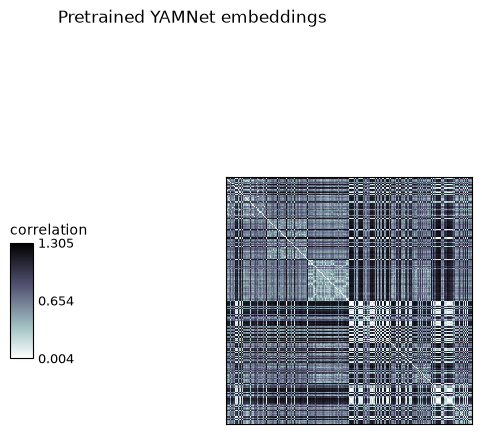

In [7]:
from core import load_yamnet_activations
import torch

# Rows follow the same sound order as SantoroDataset.
yamnet_activations = load_yamnet_activations(layer="embedding")
yamnet_embeddings = torch.as_tensor(yamnet_activations["embedding"])

print("YAMNet embeddings shape:", tuple(yamnet_embeddings.shape))

rdm_yamnet = calculate_rdm(yamnet_embeddings)

fig, axes, handles = rsa.vis.show_rdm(
    rdm_yamnet,
    show_colorbar="figure",
    figsize=(7, 6),
)
fig.suptitle("Pretrained YAMNet embeddings")
plt.show()

### 2. Compare the models to the brain data

We compare each model RDM with the STG brain RDM using Spearman correlation. This checks whether the model and brain put sound differences in a similar order. A higher score means more agreement.

We use only the top half of each RDM, without the diagonal. This avoids counting the same sound pair twice or comparing a sound with itself.

We use five runs per model. We show the average and a 95% confidence interval across runs. We have brain data from one person, so these intervals do not tell us how results vary across people.

The untrained models are new random models. They are not the saved starting versions of the trained models, so we compare the two groups as independent groups.


In [ ]:
from itertools import combinations

from scipy.stats import spearmanr, t, ttest_ind

brain_matrix = rdm_stg.get_matrices()[0]
upper = np.triu_indices_from(brain_matrix, k=1)
brain_distances = brain_matrix[upper]

def brain_alignment(rdm):
    matrix = rdm.get_matrices()[0]
    if matrix.shape != brain_matrix.shape:
        raise ValueError('Model and brain RDMs must contain the same sounds.')
    distances = matrix[upper]
    if not (np.isfinite(distances).all() and np.isfinite(brain_distances).all()):
        raise ValueError('An RDM contains missing or infinite values.')
    score = float(spearmanr(brain_distances, distances).statistic)
    if not np.isfinite(score):
        raise ValueError('Cannot compare an RDM with constant distances.')
    return score

def mean_ci(values):
    values = np.asarray(values, dtype=float)
    mean = values.mean(axis=0)
    margin = t.ppf(0.975, len(values) - 1) * values.std(axis=0, ddof=1) / np.sqrt(len(values))
    return mean, margin

# Each column is a layer; each row is one model run.
alignment = {'untrained': {}, 'trained': {}}
layer_names = {}
for model_name in MODEL_CLASSES:
    layers = list(next(iter(trained_rdms[model_name].values())))
    layer_names[model_name] = layers
    for condition, rdms in [('untrained', untrained_rdms), ('trained', trained_rdms)]:
        alignment[condition][model_name] = np.array([
            [brain_alignment(run[layer]) for layer in layers]
            for run in rdms[model_name].values()
        ])

final_scores = {
    condition: {
        name: scores[:, layer_names[name].index('classifier')]
        for name, scores in models.items()
    }
    for condition, models in alignment.items()
}
yamnet_score = brain_alignment(rdm_yamnet)

# Six planned tests: three training comparisons and three architecture comparisons.
# Welch's test compares independent runs. Holm correction accounts for all six tests.
raw_p = {}
for name in MODEL_CLASSES:
    raw_p[('training', name)] = ttest_ind(
        final_scores['trained'][name], final_scores['untrained'][name], equal_var=False
    ).pvalue
for left, right in combinations(MODEL_CLASSES, 2):
    raw_p[('architecture', left, right)] = ttest_ind(
        final_scores['trained'][left], final_scores['trained'][right], equal_var=False
    ).pvalue

adjusted_p = {}
previous = 0.0
for rank, key in enumerate(sorted(raw_p, key=raw_p.get)):
    previous = max(previous, min(1.0, (len(raw_p) - rank) * raw_p[key]))
    adjusted_p[key] = previous
print('Scores ready. Error bars show 95% confidence intervals across runs.')

Scores ready. Error bars show 95% confidence intervals across runs.


#### a) conduct an analysis on the effect of training on brain alignment, comparing the untrained to the trained models

We compare the final layer of trained and untrained models. Each dot is one run. Each bar is the average. The error bars show 95% confidence intervals.

We use Welch's t-test to compare the groups. We use Holm correction for the six tests in 2a and 2b. This helps limit false positive results when we do several tests. There are only five runs in each group, so the evidence is limited. The tests use model runs, not individual sound pairs.


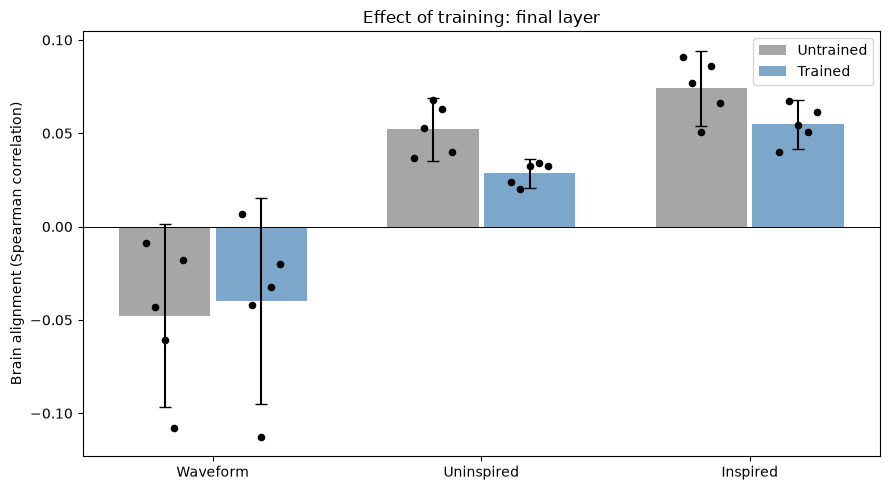

Waveform: untrained = -0.048, trained = -0.040, change = +0.008.
  Holm-adjusted p = 0.777. The test does not give clear evidence of a difference.
Uninspired: untrained = 0.052, trained = 0.029, change = -0.023.
  Holm-adjusted p = 0.06014. The test does not give clear evidence of a difference.
Inspired: untrained = 0.074, trained = 0.055, change = -0.019.
  Holm-adjusted p = 0.1206. The test does not give clear evidence of a difference.


In [9]:
names = list(MODEL_CLASSES)
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 5))
for condition, offset, color in [('untrained', -0.18, 'gray'), ('trained', 0.18, 'steelblue')]:
    means, margins = zip(*(mean_ci(final_scores[condition][name]) for name in names))
    ax.bar(x + offset, means, width=0.34, yerr=margins, capsize=4,
           color=color, alpha=0.7, label=condition.capitalize())
    for position, name in zip(x + offset, names):
        values = final_scores[condition][name]
        ax.scatter(position + np.linspace(-0.07, 0.07, len(values)), values,
                   color='black', s=20, zorder=3)
ax.set_xticks(x, [name.capitalize() for name in names])
ax.set_ylabel('Brain alignment (Spearman correlation)')
ax.set_title('Effect of training: final layer')
ax.axhline(0, color='black', linewidth=0.7)
ax.legend()
plt.tight_layout()
plt.show()

for name in names:
    before = final_scores['untrained'][name].mean()
    after = final_scores['trained'][name].mean()
    change = after - before
    p = adjusted_p[('training', name)]
    print(f'{name.capitalize()}: untrained = {before:.3f}, trained = {after:.3f}, change = {change:+.3f}.')
    print(f'  Holm-adjusted p = {p:.4g}. ' + (
        'The test supports a difference between the groups.' if p < 0.05
        else 'The test does not give clear evidence of a difference.'
    ))

**Results:** Waveform's average score rose slightly, from -0.048 to -0.040. Uninspired fell from 0.052 to 0.029. Inspired fell from 0.074 to 0.055.

All corrected p-values were above 0.05. We did not find a clear training effect on final-layer alignment in these runs.


#### b) conduct an analysis on the effect of architectural choices on brain alignment

We compare the final layers of the three trained models. Waveform uses the raw sound. Uninspired uses a spectrogram, which shows how sound frequencies change over time. Inspired also uses a recurrent network to process a sequence.

We show the YAMNet embedding score as a reference. Its training and features are different. We have only one YAMNet result, so we do not give it an error bar across runs.

The models differ in several ways. A difference in scores cannot tell us which single design choice caused it.


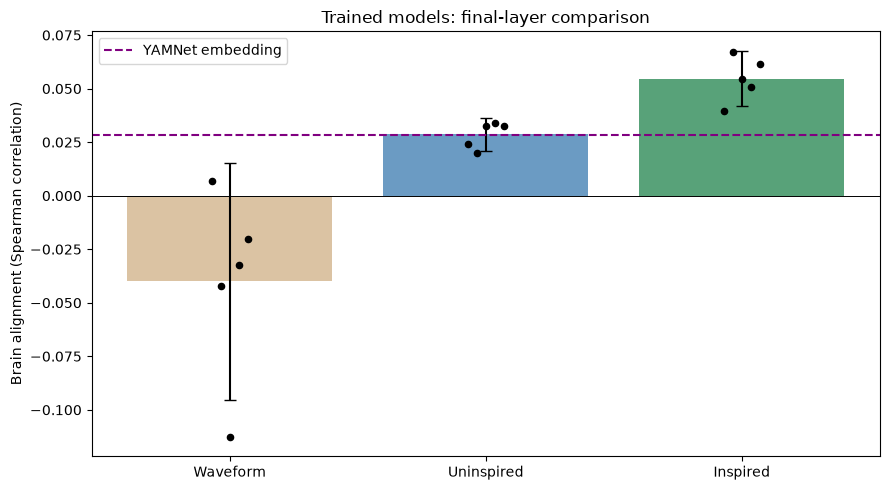

Inspired has the highest mean final-layer score among the three models.
YAMNet embedding score: 0.028.
waveform minus uninspired: -0.069; Holm-adjusted p = 0.07586.
  The test does not give clear evidence of a difference.
waveform minus inspired: -0.095; Holm-adjusted p = 0.03784.
  The test supports a difference.
uninspired minus inspired: -0.026; Holm-adjusted p = 0.01462.
  The test supports a difference.


In [10]:
means, margins = zip(*(mean_ci(final_scores['trained'][name]) for name in names))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, means, yerr=margins, capsize=4, color=['tan', 'steelblue', 'seagreen'], alpha=0.8)
for position, name in zip(x, names):
    values = final_scores['trained'][name]
    ax.scatter(position + np.linspace(-0.07, 0.07, len(values)), values, color='black', s=20)
ax.axhline(yamnet_score, color='purple', linestyle='--', label='YAMNet embedding')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(x, [name.capitalize() for name in names])
ax.set_ylabel('Brain alignment (Spearman correlation)')
ax.set_title('Trained models: final-layer comparison')
ax.legend()
plt.tight_layout()
plt.show()

best_model = max(names, key=lambda name: final_scores['trained'][name].mean())
print(f'{best_model.capitalize()} has the highest mean final-layer score among the three models.')
print(f'YAMNet embedding score: {yamnet_score:.3f}.')
for left, right in combinations(names, 2):
    difference = final_scores['trained'][left].mean() - final_scores['trained'][right].mean()
    p = adjusted_p[('architecture', left, right)]
    print(f'{left} minus {right}: {difference:+.3f}; Holm-adjusted p = {p:.4g}.')
    print('  The test supports a difference.' if p < 0.05 else '  The test does not give clear evidence of a difference.')

**Results:** Inspired had the highest average score (0.055). Next were Uninspired (0.029) and Waveform (-0.040).

The corrected tests supported a difference between Inspired and each of the other models. They did not show a clear difference between Uninspired and Waveform.

YAMNet scored 0.028. We did not run a test for YAMNet. All scores were small, so even the best result showed only weak agreement with the brain data.


#### c) conduct an analysis on how well layers at different depths of the models align with brain data of the STG

We show the layers from first to last. Higher points mean more agreement with STG. The error bars show 95% confidence intervals across runs.

The same layer number can mean different things in different models. For Inspired, the `rnn` point is the output of the final GRU layer. The helper does not show both GRU layers separately.

We name the layer with the highest average score in these data. We do not test differences between layers. The best layer here may not be the best on new data.


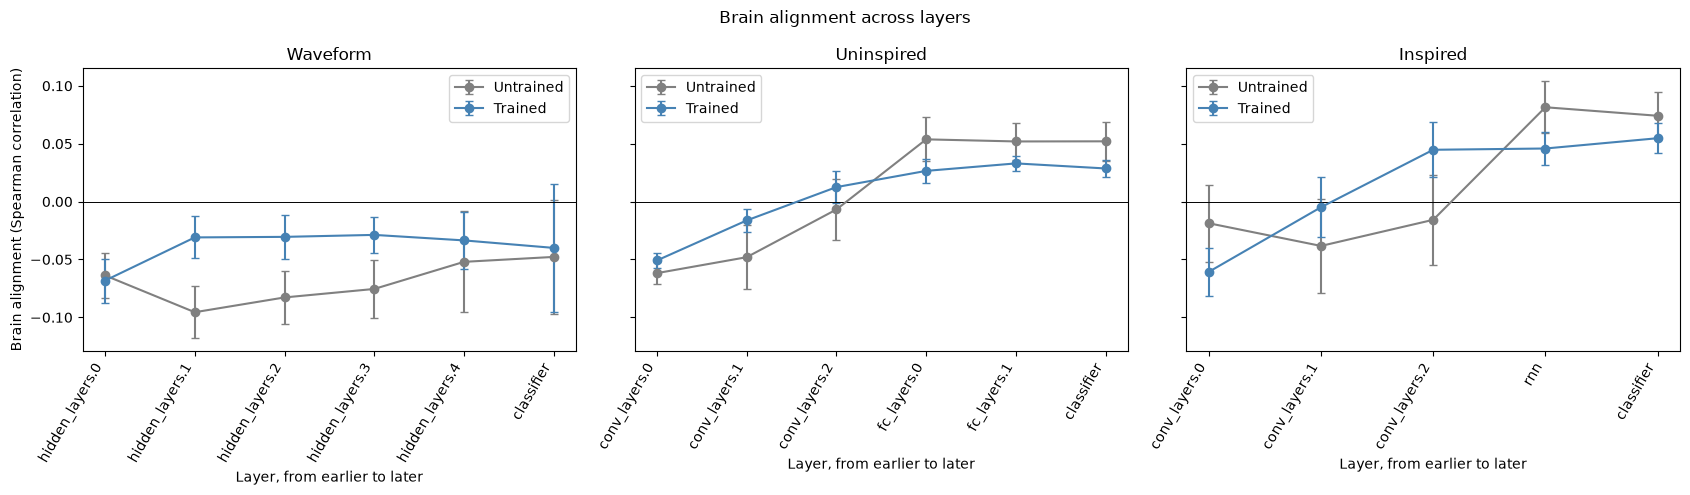

Waveform: highest trained mean at hidden_layers.3 (-0.029).
  First layer = -0.068; final layer = -0.040.
Uninspired: highest trained mean at fc_layers.1 (0.033).
  First layer = -0.051; final layer = 0.029.
Inspired: highest trained mean at classifier (0.055).
  First layer = -0.061; final layer = 0.055.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, name in zip(axes, names):
    layers = layer_names[name]
    positions = np.arange(len(layers))
    for condition, color in [('untrained', 'gray'), ('trained', 'steelblue')]:
        means, margins = mean_ci(alignment[condition][name])
        ax.errorbar(positions, means, yerr=margins, marker='o', capsize=3,
                    color=color, label=condition.capitalize())
    ax.set_xticks(positions, layers, rotation=60, ha='right')
    ax.set_title(name.capitalize())
    ax.set_xlabel('Layer, from earlier to later')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.legend()
axes[0].set_ylabel('Brain alignment (Spearman correlation)')
fig.suptitle('Brain alignment across layers')
plt.tight_layout()
plt.show()

for name in names:
    means, _ = mean_ci(alignment['trained'][name])
    best = int(np.argmax(means))
    print(f'{name.capitalize()}: highest trained mean at {layer_names[name][best]} ({means[best]:.3f}).')
    print(f'  First layer = {means[0]:.3f}; final layer = {means[-1]:.3f}.')

**Results:** The highest trained average was:

- Waveform: `hidden_layers.3`, with -0.029.
- Uninspired: `fc_layers.1`, with 0.033.
- Inspired: `classifier`, with 0.055.

All three models scored higher at the final layer than at the first layer. But the final layer was not always the best: Waveform and Uninspired had their highest scores earlier.

Waveform's highest average was still negative. These results describe this dataset; they do not show that the same layers will be best on new data.


### 3. t-SNE visualisation


Calculating t-SNE embeddings (from N-dimensions to 2D)


In [24]:
def feature_matrix(values):
    if isinstance(values, torch.Tensor):
        values = values.detach().cpu().numpy()

    values = np.asarray(values)
    return values.reshape(values.shape[0], -1)

def calculate_tsne(values):
    X = feature_matrix(values)

    tsne_model = TSNE(
        n_components=2, 
        perplexity=30,
        metric='correlation',
        init='random',
        max_iter=1500,
        random_state=67
    )

    return tsne_model.fit_transform(X)

def plot_tsne(ax, tsne_embeddings):
    ax.scatter(
        tsne_embeddings[:, 0],
        tsne_embeddings[:, 1],
        c=category_numbers,
        cmap="turbo",
        s=22,
        alpha=0.8,
    )
    ax.set_xticks([])
    ax.set_yticks([])

In [22]:
from sklearn.manifold import TSNE

labels = np.asarray(dataset.categories)
unique_cats = sorted(set(labels))

category_to_number = {
    category: i for i, category in enumerate(unique_cats)
}

category_numbers = np.array([category_to_number[label] for label in labels])

#### a) STG responses


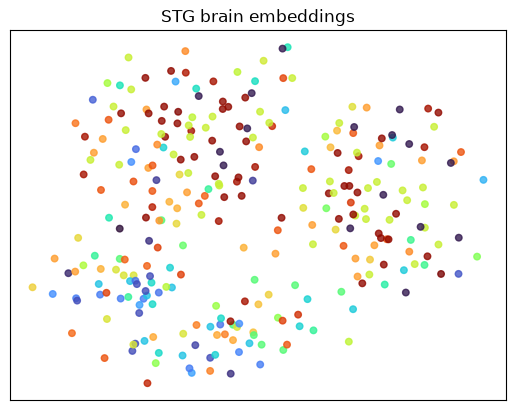

In [25]:
stg_tsne = calculate_tsne(dataset.brain_responses)

ax = plt.subplot(1,1,1)

plot_tsne(ax, stg_tsne)
ax.set_title("STG brain embeddings")

plt.show()

#### b) Untrained models


Model: waveform


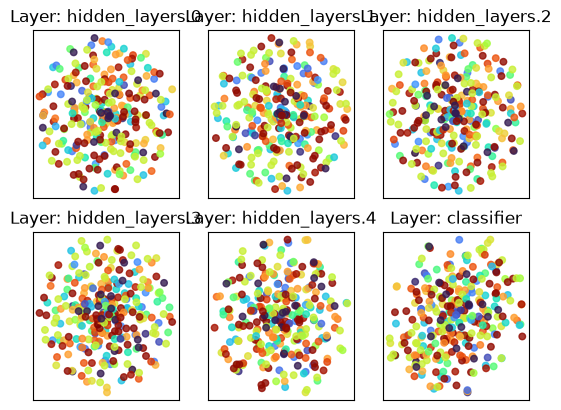

Model: uninspired


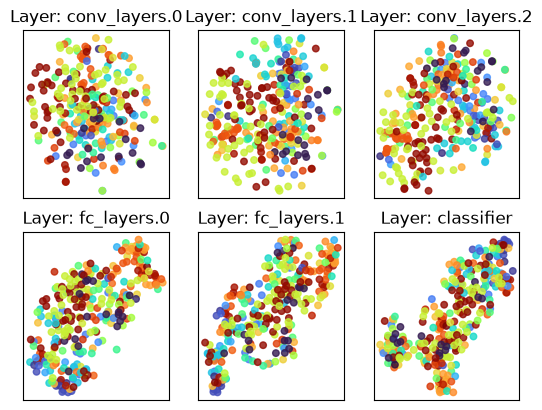

Model: inspired


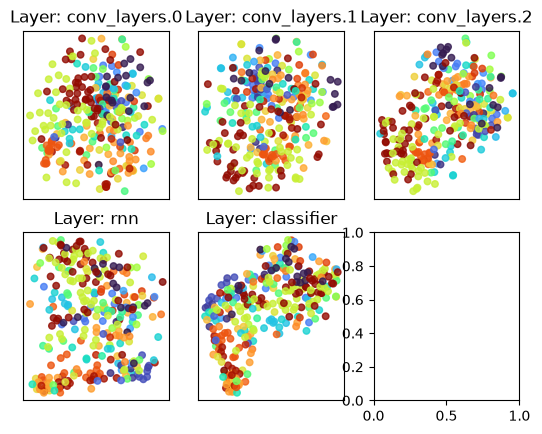

In [31]:
import torch

loader = DataLoader(dataset, batch_size=16, shuffle=False)

seed = 44
torch.manual_seed(seed)


for model_name, ModelClass in MODEL_CLASSES.items():
    model = ModelClass(num_classes=50)
    activations = extract_activations(loader, model)

    fig, axes = plt.subplots(2, 3)

    print("Model:", model_name)

    for ax, (layer_name, layer_act) in zip(np.asarray(axes).reshape(-1), activations.items()):
        layer_tsne = calculate_tsne(layer_act)

        plot_tsne(ax, layer_tsne)
        ax.set_title(f"Layer: {layer_name}")


    plt.show()